# Assignment 4 - Inventory and Capacity Planning

# Part I: Inventory & Capacity Planning  | Hyatt’s Problem (Overbooking level optimization)

In [1]:
# Capacity: 100 rooms
# Room price: $150 =
# Demand forecast for no-shows: normal with mean 8, standard deviation 2
# $175 = Cost of someone who no shows

In [2]:
import numpy as np
import pandas as pd

In [3]:
# set input parameters
capacity = 100
room_price = 150
voucher = 25
no_show_mean = 8
no_show_sd = 2

# simulaion-specific parameter
simulation_run = 400000

<Axes: ylabel='Frequency'>

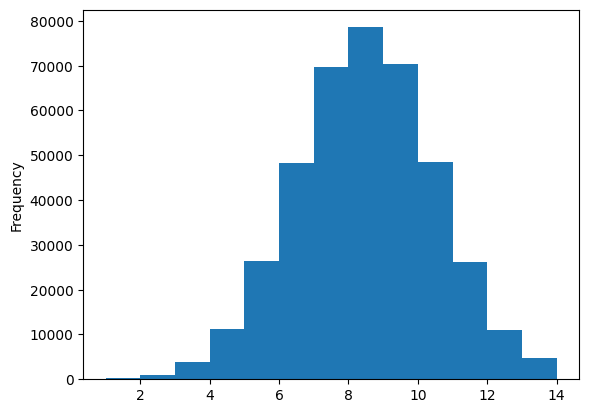

In [4]:
# numpy.random.seed(12345)
df_no_show = pd.DataFrame({'no_shows' : np.random.normal(no_show_mean, no_show_sd, simulation_run).round()})

df_no_show.no_shows.plot.hist(bins=range(1,15))

In [5]:
# as a rule of thumb, try protection levels between
# mean - 3SD, mean + 3SD
df_optimize = pd.DataFrame({'Y' : np.arange(2,15)})
df_optimize

,Y
0,2
1,3
2,4
3,5
4,6
5,7
6,8
7,9
8,10
9,11


In [6]:
df_optimize = pd.DataFrame({'overbook_level': np.arange(2,15)})
df_optimize

,overbook_level
0,2
1,3
2,4
3,5
4,6
5,7
6,8
7,9
8,10
9,11


In [7]:
# use a loop to try different protection levels and compute average profit
for i in np.arange(0,df_optimize.shape[0]):

    # Calculate how much revenue actually earned
    df_no_show['overbook_level'] = df_optimize.overbook_level[i]
    df_no_show['net_rooms'] = (capacity + df_no_show.overbook_level - df_no_show.no_shows).clip(upper=capacity)
    df_no_show['room_rev'] = df_no_show.net_rooms * room_price

    # Calculate how much taken as losses (150 + 25 = 175 for each overbooked room)
    df_no_show['denials'] = (df_optimize.overbook_level[i] - df_no_show.no_shows).clip(lower=0)
    df_no_show['denial_cost'] = df_no_show.denials * voucher
    df_no_show['empty_rooms'] = (df_no_show.no_shows - df_optimize.overbook_level[i]).clip(lower=0)
    df_no_show['opportunity_cost'] = df_no_show.empty_rooms * room_price

    # Calculate profit
    df_no_show['profit'] = df_no_show.room_rev - (df_no_show.denial_cost + df_no_show.opportunity_cost)

    # Aggregate
    df_optimize.loc[i,'avg_profit'] = df_no_show.profit.mean()
    df_optimize.loc[i,'sd_profit'] = df_no_show.profit.std()
    
df_optimize

,overbook_level,avg_profit,sd_profit
0,2,13200.327500,606.183923
1,3,13499.356562,603.563357
2,4,13795.276187,594.483183
3,5,14082.083625,570.963585
4,6,14347.465437,522.896433
5,7,14573.681500,445.326935
6,8,14743.277687,344.742023
7,9,14849.033312,239.528967
8,10,14897.675063,150.218766
9,11,14906.861812,90.195568


In [8]:
# Check intermediate calculations to see if things look normal
df_optimize.sort_values("avg_profit", ascending=False)

,overbook_level,avg_profit,sd_profit
9,11,14906.861812,90.195568
8,10,14897.675063,150.218766
10,12,14894.790312,61.004057
11,13,14873.761813,52.274399
12,14,14849.740062,50.793176
7,9,14849.033312,239.528967
6,8,14743.277687,344.742023
5,7,14573.681500,445.326935
4,6,14347.465437,522.896433
3,5,14082.083625,570.963585


[Text(0, 0.5, 'Expected Profit (avg_profit)'),
 Text(0.5, 0, 'Uncertainty (sd_profit)')]

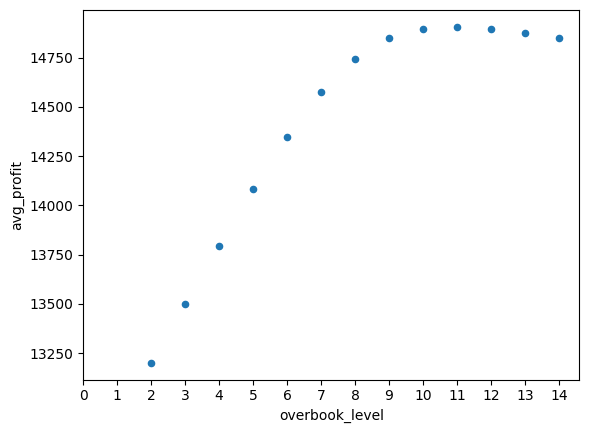

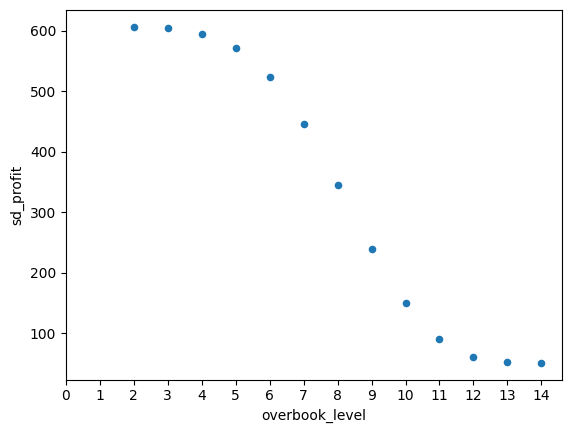

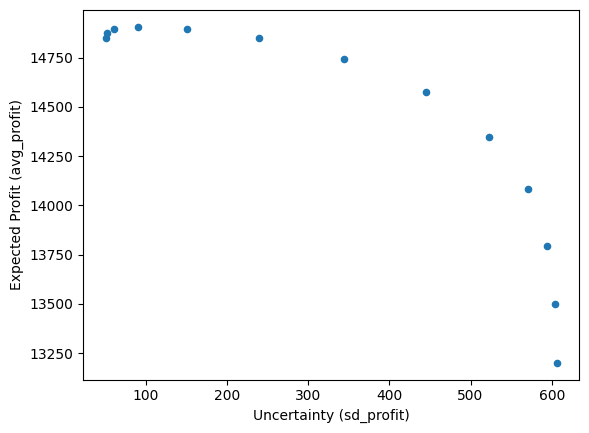

In [9]:
# Relationship between avg and sd of profit with overbooking level
df_optimize.plot.scatter(x='overbook_level',y='avg_profit',xticks=range(0,15))
df_optimize.plot.scatter(x='overbook_level',y='sd_profit',xticks=range(0,15))

# Profit risk: efficiency frontier
df_optimize.plot.scatter(y='avg_profit',x='sd_profit').set(ylabel="Expected Profit (avg_profit)", xlabel="Uncertainty (sd_profit)")

Based on our simulation (400,000 runs), the overbooking level that maximized the average profit was an overbooking level of 11. When we used this level for the simulation, we end with an average profit of $14906.86, with a standard deviation of 90.19. The standard deviation being 90.19 is especially notable in this result because at some of the other booking levels, especially at the extreme ends (2-4, 13-14), we had standard deviations in the range of 500-600, indicating much more variance in the results.

With the overbooking level set to 11, not only do we maximize the average profit (if only slightly above some of the other nearby levels), we also benefit from a more stable forecast, where in a majority of scenarios, we should expect a profit within about $100 of this average estimate, as indicated by the standard deviation.

# Part II: Inventory & Capacity Planning  | The Parka Problem (Inventory level optimization)

In [10]:
procurement_cost = 70
new_item_price = 140
markdown_item_price = 40
parka_mean = 26
parka_sd = 3

simulation_runs = 400000

In [11]:
df_parka = pd.DataFrame({'parka_demand': np.round(np.random.normal(parka_mean, parka_sd, simulation_runs),0)})
df_parka

,parka_demand
0,21.0
1,28.0
2,23.0
3,26.0
4,24.0
...,...
399995,21.0
399996,25.0
399997,30.0
399998,26.0


In [12]:
# Get all levels of invenetory to test - 3SD +- (26+-9 = 17 - 35)
df_optimize = pd.DataFrame({'order_size': np.arange(17, 36)})
df_optimize

,order_size
0,17
1,18
2,19
3,20
4,21
5,22
6,23
7,24
8,25
9,26


In [13]:
# use a loop to try different order sizes and calculate average profits
for i in np.arange(0,df_optimize.shape[0]):

    # Calculate how many parkas were sold at each price
    df_parka['full_price_parkas'] = (df_parka.parka_demand).clip(upper=df_optimize.order_size[i]) # order_size - demand, clip upper at ordersize since we cant sell more than we have
    df_parka['markdown_parkas'] = (df_optimize.order_size[i] - df_parka.full_price_parkas).clip(lower=0) # total order size - full priced parkas, clip lower at 0 since we cant have negative parkas at markdown

    # Calculate revenue for different parka orders
    df_parka['full_price_rev'] = df_parka.full_price_parkas * new_item_price
    df_parka['markdown_price_rev'] = df_parka.markdown_parkas * markdown_item_price

    # Calculate cost
    df_parka['procurement_cost'] = df_optimize.order_size[i] * procurement_cost # Total cost of production for all parkas

    # Calculate profit
    df_no_show['profit'] = (df_parka.full_price_rev + df_parka.markdown_price_rev) - df_parka.procurement_cost

    # Aggregate
    df_optimize.loc[i,'avg_profit'] = df_no_show.profit.mean()
    df_optimize.loc[i,'sd_profit'] = df_no_show.profit.std()

In [14]:
df_optimize.sort_values(by="avg_profit", ascending=False)

,order_size,avg_profit,sd_profit
11,28,1715.26400,238.829401
10,27,1714.35275,209.868718
12,29,1705.51650,261.854214
9,26,1700.92525,176.764835
13,30,1687.67925,278.440690
8,25,1674.30675,142.191095
14,31,1664.37425,289.266115
15,32,1637.72225,295.608111
7,24,1635.11975,108.977832
16,33,1609.24750,298.950844


[Text(0, 0.5, 'Expected Profit (avg_profit)'),
 Text(0.5, 0, 'Uncertainty (sd_profit)')]

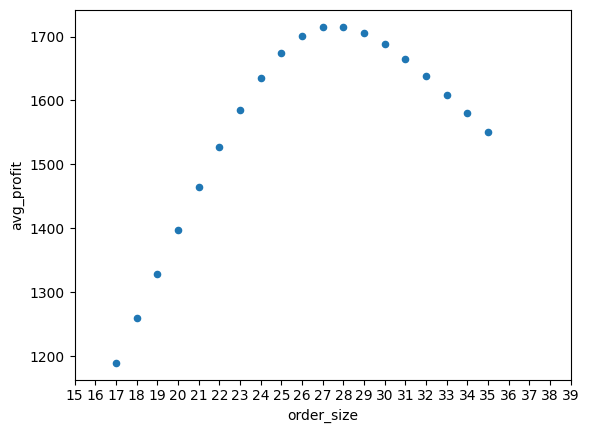

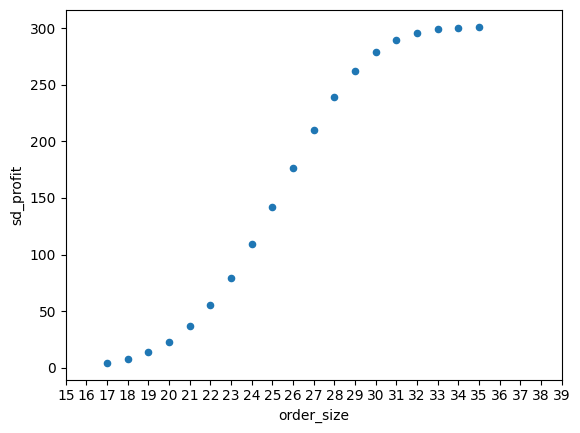

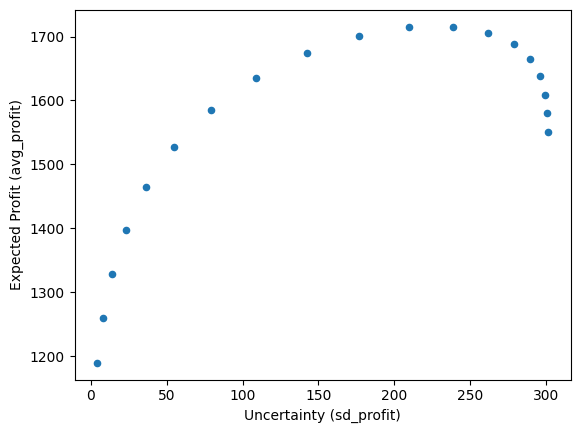

In [15]:
# Relationship between avg and sd of profit with overbooking level
df_optimize.plot.scatter(x='order_size',y='avg_profit',xticks=range(15,40))
df_optimize.plot.scatter(x='order_size',y='sd_profit',xticks=range(15,40))

# Profit risk: efficiency frontier
df_optimize.plot.scatter(y='avg_profit',x='sd_profit').set(ylabel="Expected Profit (avg_profit)", xlabel="Uncertainty (sd_profit)")

For the Parka example, we find that an order size of 28 maximizes the average profit ever so slightly over an order size of 27, with $1715 compared to $1714. These two values are very close to each other, making it seem like either would work just fine. By comparing the standard deviations of each, we can see if there are any other advantages to consider.

For order size = 28, we have an SD of 238.8, compared to the SD of order_size = 27 which was 209.9 approxiately. This is a non-trivial difference; even though 28 technically maximized the profit slightly, it did so at the cost of higher variance, which means there is just a possibility that due to the random nature of demand (assuming it is normally distributed), there exists scenarios where the profit with an order size of 28 could perform worse than 27 due to the wider variance range. This means that while 27 and 28 perform very similarly profit wise, the lower standard deviation on 27 may make it actually a bit more favorable to use that value, even if there is a small cost in terms of average profit (only a single $ in this simulation)